# Tutorial 5 — MAE Pretraining with YOLOv26 for Brain-Tumor Segmentation

**Course:** CSE445 — Computer Vision  
**Instructor:** Dr Mohammad Rifat Ahmmad Rashid  

**Dataset:** Brain Tumor Image Dataset — Semantic Segmentation  
**Kaggle source:** `pkdarabi/brain-tumor-image-dataset-semantic-segmentation`

**Pipeline:** unlabeled MRI images → random patch masking → YOLOv26 multi-scale encoder → lightweight reconstruction decoder → transfer the MAE-trained YOLOv26 weights → supervised tumor segmentation → held-out evaluation.

This notebook implements a **convolutional masked autoencoder adapted to the YOLOv26 segmentation backbone**. It retains the central MAE principle—hide a large fraction of the input and reconstruct the missing content—while using YOLOv26 feature maps instead of Vision Transformer patch tokens.

> Two epochs are intentionally configured for a fast classroom/Kaggle demonstration. They are not sufficient for a final research comparison.

## How MAE + YOLOv26 works

For an MRI image $x$, divide the image into non-overlapping patches. A binary patch mask $M$ hides a fraction $r$ of the patches:

$$
\tilde{x} = x \odot (1-M),
$$

where $	ilde{x}$ is the masked input. The YOLOv26 encoder $f_{\theta}$ extracts multi-scale feature maps:

$$
\{F_1,F_2,F_3\}=f_{\theta}(\tilde{x}).
$$

A lightweight decoder $d_{\phi}$ fuses the multi-scale features and predicts the reconstructed image:

$$
\hat{x}=d_{\phi}(F_1,F_2,F_3).
$$

The reconstruction loss is computed only over hidden pixels:

$$
\mathcal{L}_{\mathrm{MAE}}
=
\frac{
\sum M\odot(\hat{x}-x)^2
}{
3\sum M+\epsilon
}.
$$

After MAE pretraining:

1. discard the reconstruction decoder;
2. retain the MAE-trained YOLOv26 segmentation network;
3. create an Ultralytics-compatible checkpoint;
4. fine-tune the complete model using tumor polygon annotations.

```text
Original MRI ──> random patch mask ──> masked MRI
                                           │
                                           ▼
                                YOLOv26 multi-scale encoder
                                           │
                              feature maps at several scales
                                           │
                                           ▼
                              reconstruction decoder ──> MRI reconstruction
                                           │
                               loss only on hidden patches

After pretraining: keep YOLOv26 encoder weights, discard decoder, fine-tune segmentation.
```

### Why this is called a CNN-adapted MAE

The original MAE architecture is usually described with a Vision Transformer encoder and a token decoder. YOLOv26 is convolutional and produces a feature pyramid. Therefore, this notebook masks spatial patches in the image and reconstructs them from fused YOLOv26 feature maps. The self-supervised learning objective remains masked reconstruction, but the encoder/decoder implementation is adapted to YOLO.

## Learning objectives

Students will learn to:

1. explain masked-image modeling and the MAE objective;
2. generate random non-overlapping patch masks;
3. use a YOLOv26 segmentation network as a self-supervised encoder;
4. fuse multi-scale YOLO feature maps for image reconstruction;
5. compute reconstruction loss only over masked regions;
6. transfer the learned YOLOv26 weights to semantic/instance segmentation;
7. compare MAE initialization with random and supervised initialization.

In [1]:
# Cell 1 — Install dependencies
!pip install -q -U ultralytics lxml scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 115.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [2]:
# Cell 2 — Imports, configuration, reproducibility, and device
import copy
import json
import math
import os
import random
import shutil
import time
import warnings
from contextlib import nullcontext
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.manifold import TSNE

from ultralytics import YOLO
import ultralytics

warnings.filterwarnings("ignore", category=UserWarning)


@dataclass
class CFG:
    seed: int = 42
    num_workers: int = 2
    prefetch_factor: int = 2
    persistent_workers: bool = True

    # Exact path requested by the user. The resolver below also supports the
    # shorter Kaggle mount path if Kaggle exposes the dataset that way.
    data_root: str = "/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation"
    working_root: str = "/kaggle/working/cse445_mae_yolov26"
    prepared_dataset_name: str = "brain_tumor_yolo_seg"

    # Ultralytics segmentation architecture.
    yolo_model: str = "yolo26n-seg.yaml"

    # Stage A — MAE pretraining.
    ssl_image_size: int = 320
    ssl_batch_size: int = 12
    ssl_epochs: int = 5
    ssl_learning_rate: float = 3e-4
    ssl_weight_decay: float = 1e-4
    gradient_accumulation_steps: int = 1
    mask_ratio: float = 0.75
    patch_size: int = 16
    decoder_dim: int = 128
    use_channels_last: bool = True
    use_torch_compile: bool = False

    # Stage B — supervised segmentation fine-tuning.
    segmentation_image_size: int = 640
    segmentation_batch_size: int = 8
    segmentation_epochs: int = 10
    segmentation_patience: int = 5

    debug_subset: Optional[int] = None
    tsne_max_samples: int = 300


cfg = CFG()

if cfg.ssl_image_size % cfg.patch_size != 0:
    raise ValueError("ssl_image_size must be divisible by patch_size.")
if not 0.0 < cfg.mask_ratio < 1.0:
    raise ValueError("mask_ratio must be between 0 and 1.")

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = device.type == "cuda"

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

# Resolve both possible Kaggle mount conventions.
requested_root = Path(cfg.data_root)
alternative_roots = [
    requested_root,
    Path("/kaggle/input/brain-tumor-image-dataset-semantic-segmentation"),
]

DATA_ROOT = next((path for path in alternative_roots if path.exists()), requested_root)
if not DATA_ROOT.exists() and Path("/kaggle/input").exists():
    discovered = sorted(
        path for path in Path("/kaggle/input").iterdir()
        if path.is_dir() and "brain-tumor" in path.name.lower()
    )
    if discovered:
        DATA_ROOT = discovered[0]

WORKING_ROOT = Path(cfg.working_root)
PREPARED_ROOT = WORKING_ROOT / cfg.prepared_dataset_name
SSL_OUTPUT_DIR = WORKING_ROOT / "mae_outputs"
SEGMENTATION_PROJECT_DIR = WORKING_ROOT / "segmentation_runs"

for directory in [WORKING_ROOT, SSL_OUTPUT_DIR, SEGMENTATION_PROJECT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
    SCALER = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
else:
    SCALER = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


def amp_context():
    if AMP_ENABLED:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def unwrap_model(model):
    return model._orig_mod if hasattr(model, "_orig_mod") else model


print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("Device:", device)
print("Resolved dataset root:", DATA_ROOT)
print("MAE epochs:", cfg.ssl_epochs)
print("Segmentation epochs:", cfg.segmentation_epochs)
display(pd.DataFrame([asdict(cfg)]).T.rename(columns={0: "value"}))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.95
PyTorch: 2.10.0+cu128
Device: cuda
Resolved dataset root: /kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation
MAE epochs: 5
Segmentation epochs: 10


,value
seed,42
num_workers,2
prefetch_factor,2
persistent_workers,True
data_root,/kaggle/input/datasets/pkdarabi/brain-tumor-im...
working_root,/kaggle/working/cse445_mae_yolov26
prepared_dataset_name,brain_tumor_yolo_seg
yolo_model,yolo26n-seg.yaml
ssl_image_size,320
ssl_batch_size,12


## 1. Prepare the Kaggle brain-tumor segmentation dataset

The Kaggle dataset is commonly exported in a Roboflow-style COCO layout:

```text
dataset-root/
├── train/
│   ├── _annotations.coco.json
│   └── image files
├── valid/
│   ├── _annotations.coco.json
│   └── image files
└── test/
    ├── _annotations.coco.json
    └── image files
```

Each COCO annotation contains one or more tumor polygons. Ultralytics segmentation labels use one row per polygon:

$$
c,\quad x_1/W,\quad y_1/H,\quad x_2/W,\quad y_2/H,\ldots,x_n/W,\quad y_n/H.
$$

The conversion cells recursively locate the COCO annotation files, preserve the supplied train/validation/test split, normalize polygon coordinates, remove invalid polygons, and create an Ultralytics-compatible `data.yaml`. The original Kaggle input is never modified.


In [3]:
# Cell 3 — Discover and parse COCO segmentation annotations
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root was not found: {DATA_ROOT}\n"
        "Attach the Kaggle dataset or update CFG.data_root."
    )

annotation_files = sorted(DATA_ROOT.rglob("*annotations*.json"))
if not annotation_files:
    annotation_files = sorted(DATA_ROOT.rglob("*.json"))

if not annotation_files:
    raise FileNotFoundError(
        f"No COCO JSON annotation file was found under {DATA_ROOT}."
    )


def infer_split_name(annotation_path):
    text = " ".join(part.lower() for part in annotation_path.parts)
    if "train" in text:
        return "train"
    if "valid" in text or "val" in text:
        return "val"
    if "test" in text:
        return "test"
    return None


def locate_coco_image(annotation_path, file_name):
    candidates = [
        annotation_path.parent / file_name,
        annotation_path.parent / Path(file_name).name,
        DATA_ROOT / file_name,
        DATA_ROOT / Path(file_name).name,
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return candidate

    matches = list(DATA_ROOT.rglob(Path(file_name).name))
    return matches[0] if matches else None


def polygon_area(flat_polygon):
    points = np.asarray(flat_polygon, dtype=np.float64).reshape(-1, 2)
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * abs(
        np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))
    )


all_records = []
category_id_to_name = {}
failed_items = []

for annotation_path in annotation_files:
    split_name = infer_split_name(annotation_path)
    if split_name is None:
        continue

    try:
        coco = json.loads(annotation_path.read_text(encoding="utf-8"))
    except Exception as error:
        failed_items.append((str(annotation_path), str(error)))
        continue

    local_categories = {
        int(category["id"]): str(category["name"])
        for category in coco.get("categories", [])
    }
    category_id_to_name.update(local_categories)

    annotations_by_image = {}
    for annotation in coco.get("annotations", []):
        annotations_by_image.setdefault(int(annotation["image_id"]), []).append(annotation)

    for image_info in coco.get("images", []):
        image_id = int(image_info["id"])
        image_path = locate_coco_image(annotation_path, image_info["file_name"])
        if image_path is None:
            failed_items.append((image_info["file_name"], "image not found"))
            continue

        width = int(image_info.get("width", 0))
        height = int(image_info.get("height", 0))
        if width <= 0 or height <= 0:
            with Image.open(image_path) as image:
                width, height = image.size

        polygon_instances = []
        for annotation in annotations_by_image.get(image_id, []):
            category_id = int(annotation["category_id"])
            segmentation = annotation.get("segmentation", [])

            # This notebook expects polygon-style COCO annotations. Compressed
            # RLE masks require pycocotools and contour extraction.
            if not isinstance(segmentation, list):
                continue

            for polygon in segmentation:
                if not isinstance(polygon, list) or len(polygon) < 6:
                    continue
                if len(polygon) % 2 != 0:
                    polygon = polygon[:-1]
                if len(polygon) < 6 or polygon_area(polygon) <= 1.0:
                    continue

                polygon_instances.append({
                    "category_id": category_id,
                    "category_name": local_categories.get(category_id, str(category_id)),
                    "polygon": polygon,
                })

        all_records.append({
            "split": split_name,
            "image_path": str(image_path),
            "width": width,
            "height": height,
            "polygons": polygon_instances,
            "number_of_masks": len(polygon_instances),
        })

dataset_frame = pd.DataFrame(all_records)
if dataset_frame.empty:
    raise RuntimeError("No valid COCO image records were found.")

if cfg.debug_subset is not None:
    sampled_parts = []
    for split_name, split_frame in dataset_frame.groupby("split"):
        sampled_parts.append(
            split_frame.sample(
                min(cfg.debug_subset, len(split_frame)),
                random_state=cfg.seed,
            )
        )
    dataset_frame = pd.concat(sampled_parts, ignore_index=True)

category_names = sorted(set(category_id_to_name.values()))
category_name_to_yolo_id = {
    category_name: index
    for index, category_name in enumerate(category_names)
}
class_names = category_names

print(f"Annotation files: {len(annotation_files)}")
print(f"Valid images: {len(dataset_frame):,}")
print(f"Skipped items: {len(failed_items):,}")
print("Split counts:")
display(dataset_frame["split"].value_counts().rename_axis("split").to_frame("images"))
print("Classes:", class_names)
display(dataset_frame[["split", "image_path", "width", "height", "number_of_masks"]].head())


Annotation files: 3
Valid images: 2,146
Skipped items: 0
Split counts:


,images
split,
train,1502
val,429
test,215


Classes: ['0', '1', 'Tumor']


,split,image_path,width,height,number_of_masks
0,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
1,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
2,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
3,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
4,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1


In [4]:
# Cell 4 — Export Ultralytics polygon-segmentation labels
def polygon_to_yolo_line(instance, width, height):
    class_id = category_name_to_yolo_id[instance["category_name"]]
    coordinates = np.asarray(instance["polygon"], dtype=np.float64).reshape(-1, 2)

    coordinates[:, 0] = np.clip(coordinates[:, 0] / width, 0.0, 1.0)
    coordinates[:, 1] = np.clip(coordinates[:, 1] / height, 0.0, 1.0)

    flattened = coordinates.reshape(-1)
    if len(flattened) < 6:
        return None

    return f"{class_id} " + " ".join(f"{value:.6f}" for value in flattened)


split_frames = {
    split_name: split_frame.reset_index(drop=True)
    for split_name, split_frame in dataset_frame.groupby("split")
}

required_splits = {"train", "val", "test"}
missing_splits = required_splits - set(split_frames)
if missing_splits:
    raise RuntimeError(
        f"Missing expected dataset splits: {sorted(missing_splits)}. "
        "Check the Kaggle directory structure."
    )

if PREPARED_ROOT.exists():
    shutil.rmtree(PREPARED_ROOT)

for split_name in required_splits:
    (PREPARED_ROOT / "images" / split_name).mkdir(parents=True, exist_ok=True)
    (PREPARED_ROOT / "labels" / split_name).mkdir(parents=True, exist_ok=True)

manifest_rows = []

for split_name, frame in split_frames.items():
    for row_index, row in tqdm(
        frame.iterrows(),
        total=len(frame),
        desc=f"Exporting {split_name}",
        leave=False,
    ):
        source_image = Path(row["image_path"])
        destination_name = f"{row_index:06d}_{source_image.name}"
        destination_image = PREPARED_ROOT / "images" / split_name / destination_name
        destination_label = (
            PREPARED_ROOT
            / "labels"
            / split_name
            / f"{Path(destination_name).stem}.txt"
        )

        shutil.copy2(source_image, destination_image)

        label_lines = []
        for instance in row["polygons"]:
            line = polygon_to_yolo_line(
                instance,
                int(row["width"]),
                int(row["height"]),
            )
            if line is not None:
                label_lines.append(line)

        destination_label.write_text(
            "\n".join(label_lines),
            encoding="utf-8",
        )

        manifest_rows.append({
            "split": split_name,
            "image_path": str(destination_image),
            "label_path": str(destination_label),
            "number_of_masks": len(label_lines),
        })

manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(PREPARED_ROOT / "manifest.csv", index=False)

data_yaml = PREPARED_ROOT / "data.yaml"
yaml_lines = [
    f"path: {PREPARED_ROOT}",
    "train: images/train",
    "val: images/val",
    "test: images/test",
    "names:",
]
yaml_lines.extend(
    f"  {class_id}: {class_name}"
    for class_name, class_id in category_name_to_yolo_id.items()
)
data_yaml.write_text("\n".join(yaml_lines), encoding="utf-8")

summary = manifest.groupby("split").agg(
    images=("image_path", "count"),
    masks=("number_of_masks", "sum"),
    mean_masks_per_image=("number_of_masks", "mean"),
)
display(summary.round(3))
print(data_yaml.read_text())


Exporting test:   0%|          | 0/215 [00:00<?, ?it/s]

Exporting train:   0%|          | 0/1502 [00:00<?, ?it/s]

Exporting val:   0%|          | 0/429 [00:00<?, ?it/s]

,images,masks,mean_masks_per_image
split,,,
test,215,215,1.0
train,1502,1502,1.0
val,429,429,1.0


path: /kaggle/working/cse445_mae_yolov26/brain_tumor_yolo_seg
train: images/train
val: images/val
test: images/test
names:
  0: 0
  1: 1
  2: Tumor


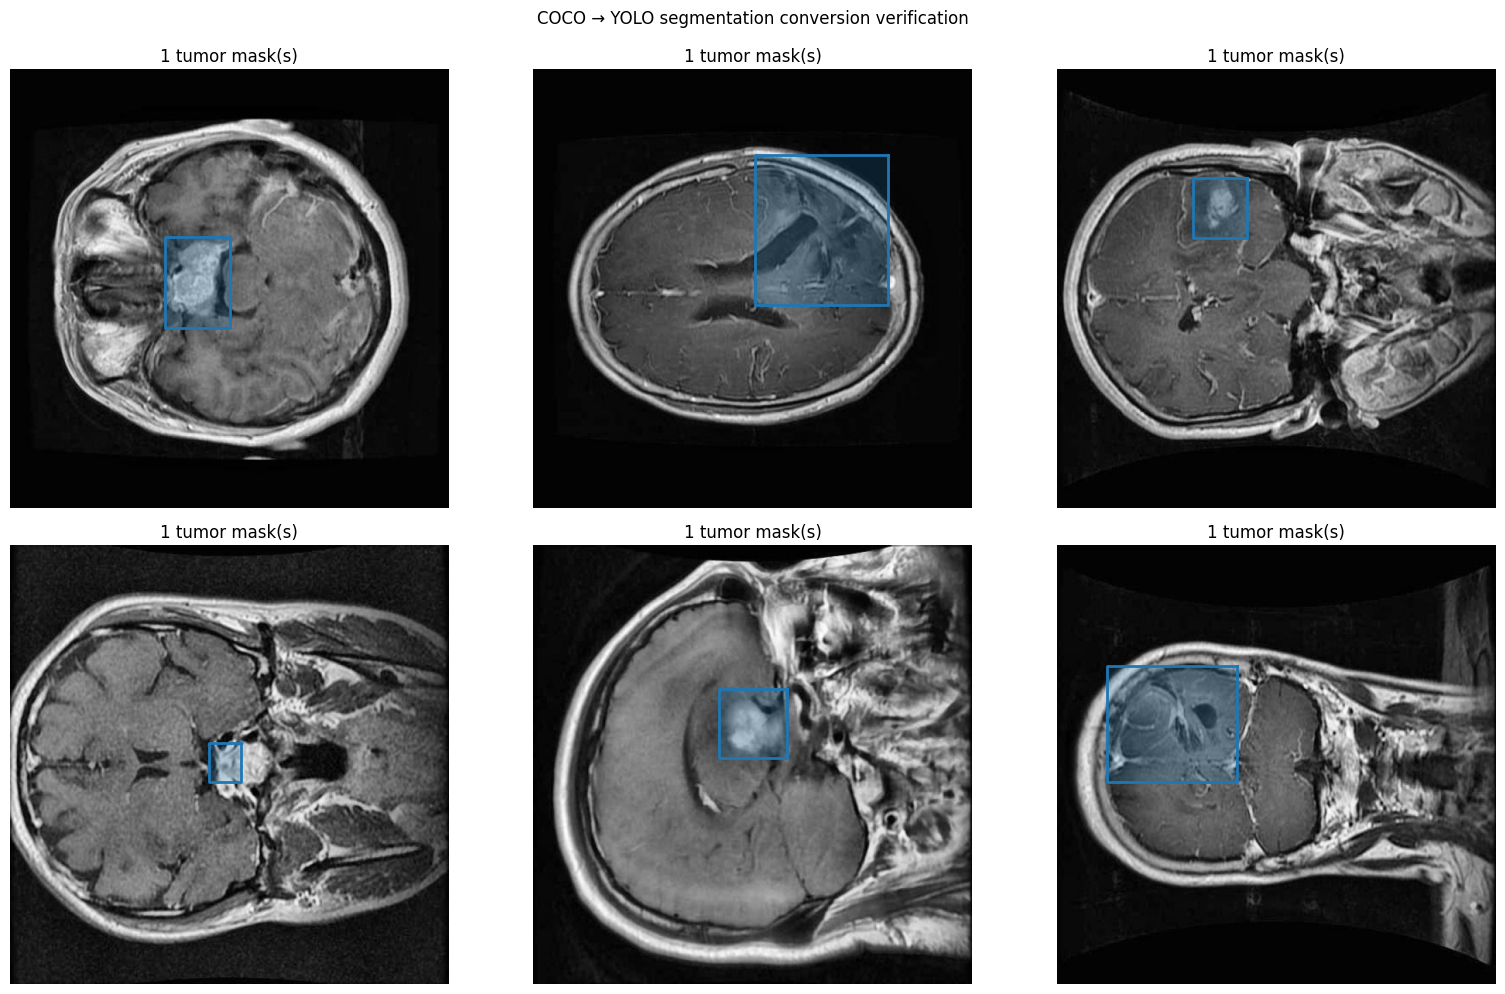

In [5]:
# Cell 5 — Visual verification of converted segmentation polygons
def read_yolo_segmentation_labels(label_path, image_width, image_height):
    instances = []
    for line in Path(label_path).read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) < 7:
            continue

        class_id = int(parts[0])
        coordinates = np.asarray(parts[1:], dtype=np.float64).reshape(-1, 2)
        coordinates[:, 0] *= image_width
        coordinates[:, 1] *= image_height
        instances.append((class_id, coordinates))
    return instances


sample_rows = manifest[manifest["split"] == "train"].sample(
    min(6, (manifest["split"] == "train").sum()),
    random_state=cfg.seed,
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = np.asarray(axes).reshape(-1)

for axis, (_, row) in zip(axes, sample_rows.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    instances = read_yolo_segmentation_labels(
        row["label_path"],
        *image.size,
    )

    axis.imshow(image)
    for class_id, polygon in instances:
        closed_polygon = np.vstack([polygon, polygon[0]])
        axis.plot(
            closed_polygon[:, 0],
            closed_polygon[:, 1],
            linewidth=2,
            label=class_names[class_id],
        )
        axis.fill(
            polygon[:, 0],
            polygon[:, 1],
            alpha=0.22,
        )

    axis.set_title(f"{len(instances)} tumor mask(s)")
    axis.axis("off")

for axis in axes[len(sample_rows):]:
    axis.axis("off")

plt.suptitle("COCO → YOLO segmentation conversion verification", y=0.99)
plt.tight_layout()
plt.show()


## 2. Stage A — MAE pretraining

The MAE stage uses only the MRI images. Polygon labels are not loaded by the MAE DataLoader.

The default mask ratio is:

$$
r=0.75,
$$

meaning that 75% of the spatial patches are hidden. For a $320\times320$ image and a patch size of $16\times16$, the image contains:

$$
N=\frac{320}{16}\times\frac{320}{16}=20\times20=400
$$

patches, of which approximately:

$$
0.75\times400=300
$$

are hidden during each forward pass.

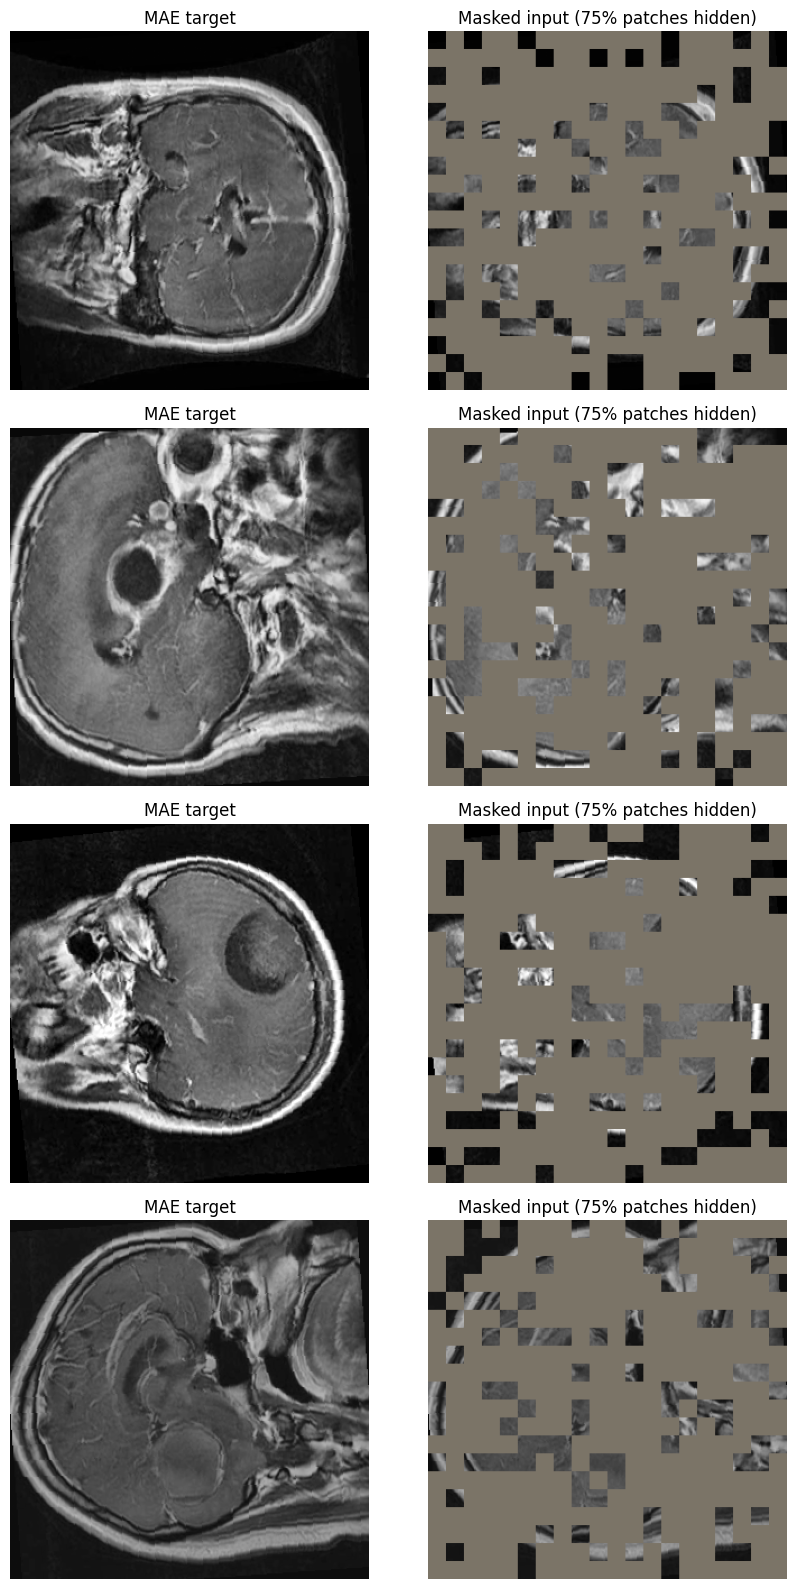

In [6]:
# Cell 6 — MAE dataset, augmentation, and patch masking
NORMALISATION_MEAN = (0.485, 0.456, 0.406)
NORMALISATION_STD = (0.229, 0.224, 0.225)

# Reconstruction-friendly augmentation: spatial and intensity variation is
# allowed, but two independent contrastive views are not required.
mae_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        cfg.ssl_image_size,
        scale=(0.75, 1.00),
        ratio=(0.90, 1.10),
        antialias=True,
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.20,
            contrast=0.20,
            saturation=0.10,
            hue=0.02,
        )
    ], p=0.50),
    transforms.ToTensor(),
    transforms.Normalize(NORMALISATION_MEAN, NORMALISATION_STD),
])

evaluation_transform = transforms.Compose([
    transforms.Resize(
        (cfg.ssl_image_size, cfg.ssl_image_size),
        antialias=True,
    ),
    transforms.ToTensor(),
    transforms.Normalize(NORMALISATION_MEAN, NORMALISATION_STD),
])


def denormalise(tensor):
    mean = torch.tensor(
        NORMALISATION_MEAN,
        dtype=tensor.dtype,
        device=tensor.device,
    ).view(3, 1, 1)
    std = torch.tensor(
        NORMALISATION_STD,
        dtype=tensor.dtype,
        device=tensor.device,
    ).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


class MAEImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = list(image_paths)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        return self.transform(image)


class SingleViewDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.loc[index]
        image = Image.open(row["image_path"]).convert("RGB")
        return evaluation_transform(image), int(row["number_of_masks"])


def create_random_patch_mask(images, patch_size, mask_ratio):
    """Mask the same number of randomly selected patches in each image.

    Returns
    -------
    masked_images : Tensor[B, C, H, W]
        Input images with hidden patches replaced by normalized zero, which
        corresponds approximately to the ImageNet mean after denormalization.
    pixel_mask : Tensor[B, 1, H, W]
        One for hidden pixels and zero for visible pixels.
    patch_mask : Tensor[B, Gh, Gw]
        Boolean patch-level mask for visualization and diagnostics.
    """
    batch_size, _, height, width = images.shape
    if height % patch_size != 0 or width % patch_size != 0:
        raise ValueError("Image height and width must be divisible by patch_size.")

    grid_h = height // patch_size
    grid_w = width // patch_size
    number_of_patches = grid_h * grid_w
    number_to_mask = max(1, int(round(number_of_patches * mask_ratio)))

    random_scores = torch.rand(
        batch_size,
        number_of_patches,
        device=images.device,
    )
    masked_indices = random_scores.argsort(dim=1)[:, :number_to_mask]

    flat_patch_mask = torch.zeros(
        batch_size,
        number_of_patches,
        dtype=torch.bool,
        device=images.device,
    )
    flat_patch_mask.scatter_(1, masked_indices, True)
    patch_mask = flat_patch_mask.view(batch_size, grid_h, grid_w)

    pixel_mask = patch_mask.repeat_interleave(
        patch_size,
        dim=1,
    ).repeat_interleave(
        patch_size,
        dim=2,
    ).unsqueeze(1).to(images.dtype)

    masked_images = images * (1.0 - pixel_mask)
    return masked_images, pixel_mask, patch_mask


ssl_train_paths = manifest.loc[
    manifest["split"] == "train", "image_path"
].tolist()
ssl_valid_paths = manifest.loc[
    manifest["split"] == "val", "image_path"
].tolist()

ssl_train_dataset = MAEImageDataset(ssl_train_paths, mae_transform)
ssl_valid_dataset = MAEImageDataset(ssl_valid_paths, evaluation_transform)

loader_kwargs = {
    "num_workers": cfg.num_workers,
    "pin_memory": AMP_ENABLED,
}
if cfg.num_workers > 0:
    loader_kwargs["persistent_workers"] = cfg.persistent_workers
    loader_kwargs["prefetch_factor"] = cfg.prefetch_factor

ssl_train_loader = DataLoader(
    ssl_train_dataset,
    batch_size=cfg.ssl_batch_size,
    shuffle=True,
    drop_last=False,
    **loader_kwargs,
)
ssl_valid_loader = DataLoader(
    ssl_valid_dataset,
    batch_size=cfg.ssl_batch_size,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)

# Visualize original and masked examples.
preview_images = torch.stack([
    ssl_train_dataset[index]
    for index in range(min(4, len(ssl_train_dataset)))
])
preview_masked, preview_pixel_mask, _ = create_random_patch_mask(
    preview_images,
    cfg.patch_size,
    cfg.mask_ratio,
)

fig, axes = plt.subplots(len(preview_images), 2, figsize=(9, 4 * len(preview_images)))
axes = np.asarray(axes).reshape(len(preview_images), 2)
for row_index in range(len(preview_images)):
    axes[row_index, 0].imshow(
        denormalise(preview_images[row_index]).permute(1, 2, 0)
    )
    axes[row_index, 0].set_title("MAE target")
    axes[row_index, 1].imshow(
        denormalise(preview_masked[row_index]).permute(1, 2, 0)
    )
    axes[row_index, 1].set_title(
        f"Masked input ({cfg.mask_ratio:.0%} patches hidden)"
    )
    for column in range(2):
        axes[row_index, column].axis("off")
plt.tight_layout()
plt.show()

In [7]:
# Cell 7 — YOLOv26 graph-aware multi-scale feature extractor
yolo = YOLO(cfg.yolo_model)
segmentation_network = yolo.model.to(device)


class UltralyticsFeatureExtractor(nn.Module):
    """Run the Ultralytics model graph up to the segmentation head inputs."""

    def __init__(self, segmentation_model):
        super().__init__()
        self.segmentation_model = segmentation_model
        self.layers = segmentation_model.model
        self.detect_layer = self.layers[-1]
        self.feature_layers = self.layers[:-1]
        self.save = set(getattr(segmentation_model, "save", []))

    @staticmethod
    def route(layer, current, saved):
        source = layer.f
        if source == -1:
            return current
        if isinstance(source, int):
            return saved[source]
        return [
            current if index == -1 else saved[index]
            for index in source
        ]

    def forward(self, images):
        saved = []
        current = images

        for layer in self.feature_layers:
            current = layer(self.route(layer, current, saved))
            saved.append(current if layer.i in self.save else None)

        sources = self.detect_layer.f
        if isinstance(sources, int):
            features = [current if sources == -1 else saved[sources]]
        else:
            features = [
                current if index == -1 else saved[index]
                for index in sources
            ]

        if any(feature is None for feature in features):
            raise RuntimeError(
                "Could not recover all feature maps consumed by the segmentation head."
            )
        return features


feature_extractor = UltralyticsFeatureExtractor(
    segmentation_network
).to(device)

with torch.inference_mode():
    dummy = torch.zeros(
        2,
        3,
        cfg.ssl_image_size,
        cfg.ssl_image_size,
        device=device,
    )
    with amp_context():
        dummy_features = feature_extractor(dummy)

feature_shapes = [tuple(feature.shape) for feature in dummy_features]
feature_channels = [int(feature.shape[1]) for feature in dummy_features]

print("YOLOv26 encoder feature shapes:", feature_shapes)
print("Feature channels:", feature_channels)

YOLOv26 encoder feature shapes: [(2, 64, 40, 40), (2, 128, 20, 20), (2, 256, 10, 10)]
Feature channels: [64, 128, 256]


In [8]:
# Cell 8 — CNN-adapted MAE model with a multi-scale reconstruction decoder
class MultiScaleReconstructionDecoder(nn.Module):
    def __init__(self, feature_channels, decoder_dim=128, output_channels=3):
        super().__init__()
        self.projections = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(channels, decoder_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(decoder_dim),
                nn.SiLU(inplace=True),
            )
            for channels in feature_channels
        ])

        fused_channels = decoder_dim * len(feature_channels)
        self.fusion = nn.Sequential(
            nn.Conv2d(
                fused_channels,
                decoder_dim * 2,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(decoder_dim * 2),
            nn.SiLU(inplace=True),
            nn.Conv2d(
                decoder_dim * 2,
                decoder_dim,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(decoder_dim),
            nn.SiLU(inplace=True),
        )

        self.reconstruction_head = nn.Sequential(
            nn.Conv2d(
                decoder_dim,
                decoder_dim,
                kernel_size=3,
                padding=1,
            ),
            nn.SiLU(inplace=True),
            nn.Conv2d(
                decoder_dim,
                decoder_dim // 2,
                kernel_size=3,
                padding=1,
            ),
            nn.SiLU(inplace=True),
            nn.Conv2d(
                decoder_dim // 2,
                output_channels,
                kernel_size=1,
            ),
        )

    def forward(self, feature_maps, output_size):
        # Fuse all features at the highest spatial resolution in the pyramid.
        target_feature_size = feature_maps[0].shape[-2:]
        projected = []
        for projection, feature_map in zip(self.projections, feature_maps):
            value = projection(feature_map)
            if value.shape[-2:] != target_feature_size:
                value = F.interpolate(
                    value,
                    size=target_feature_size,
                    mode="bilinear",
                    align_corners=False,
                )
            projected.append(value)

        fused = self.fusion(torch.cat(projected, dim=1))
        reconstructed = F.interpolate(
            fused,
            size=output_size,
            mode="bilinear",
            align_corners=False,
        )
        return self.reconstruction_head(reconstructed)


class MAEYOLO(nn.Module):
    """Masked autoencoder using a YOLOv26 multi-scale encoder."""

    def __init__(self, encoder, feature_channels, decoder_dim):
        super().__init__()
        self.encoder = encoder
        self.decoder = MultiScaleReconstructionDecoder(
            feature_channels=feature_channels,
            decoder_dim=decoder_dim,
            output_channels=3,
        )

    def forward(self, masked_images):
        feature_maps = self.encoder(masked_images)
        reconstruction = self.decoder(
            feature_maps,
            output_size=masked_images.shape[-2:],
        )
        return reconstruction, feature_maps


def masked_reconstruction_loss(reconstruction, target, pixel_mask):
    squared_error = (reconstruction.float() - target.float()).pow(2)
    denominator = pixel_mask.sum().clamp_min(1.0) * target.shape[1]
    return (squared_error * pixel_mask.float()).sum() / denominator


def masked_absolute_error(reconstruction, target, pixel_mask):
    absolute_error = (reconstruction.float() - target.float()).abs()
    denominator = pixel_mask.sum().clamp_min(1.0) * target.shape[1]
    return (absolute_error * pixel_mask.float()).sum() / denominator


mae_model = MAEYOLO(
    encoder=feature_extractor,
    feature_channels=feature_channels,
    decoder_dim=cfg.decoder_dim,
).to(device)

if AMP_ENABLED and cfg.use_channels_last:
    mae_model = mae_model.to(memory_format=torch.channels_last)

# Keep a copy for before/after representation analysis.
initial_feature_state = copy.deepcopy({
    key: value.detach().cpu()
    for key, value in unwrap_model(mae_model).encoder.state_dict().items()
})

if cfg.use_torch_compile and hasattr(torch, "compile"):
    try:
        mae_model = torch.compile(mae_model, mode="reduce-overhead")
        print("torch.compile enabled.")
    except Exception as compile_error:
        print("torch.compile could not be enabled:", compile_error)

trainable_parameters = [
    parameter
    for parameter in mae_model.parameters()
    if parameter.requires_grad
]

ssl_optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=cfg.ssl_learning_rate,
    weight_decay=cfg.ssl_weight_decay,
)
ssl_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ssl_optimizer,
    T_max=max(1, cfg.ssl_epochs),
)

parameter_count = sum(parameter.numel() for parameter in mae_model.parameters())
trainable_count = sum(parameter.numel() for parameter in trainable_parameters)

print(f"MAE total parameters: {parameter_count:,}")
print(f"MAE trainable parameters: {trainable_count:,}")
print(f"Mask ratio: {cfg.mask_ratio:.0%}")
print(f"Patch size: {cfg.patch_size} × {cfg.patch_size}")

MAE total parameters: 4,586,379
MAE trainable parameters: 4,586,379
Mask ratio: 75%
Patch size: 16 × 16


In [9]:
# Cell 9 — MAE training and validation with progress bars
def move_to_device(images):
    images = images.to(device, non_blocking=AMP_ENABLED)
    if AMP_ENABLED and cfg.use_channels_last:
        return images.contiguous(memory_format=torch.channels_last)
    return images.contiguous()


def run_mae_epoch(
    model,
    loader,
    optimizer=None,
    scaler=None,
    description="MAE",
):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_mae = 0.0
    total_mask_fraction = 0.0
    processed_batches = 0
    processed_images = 0
    start_time = time.perf_counter()

    progress = tqdm(
        loader,
        desc=description,
        dynamic_ncols=True,
        leave=False,
        unit="batch",
    )

    if training:
        optimizer.zero_grad(set_to_none=True)

    for batch_index, images in enumerate(progress, start=1):
        images = move_to_device(images)
        masked_images, pixel_mask, _ = create_random_patch_mask(
            images,
            patch_size=cfg.patch_size,
            mask_ratio=cfg.mask_ratio,
        )

        with torch.set_grad_enabled(training):
            with amp_context():
                reconstruction, _ = model(masked_images)
                loss = masked_reconstruction_loss(
                    reconstruction,
                    images,
                    pixel_mask,
                )

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite MAE reconstruction loss detected.")

            scaled_loss = loss / cfg.gradient_accumulation_steps

            if training:
                if AMP_ENABLED:
                    scaler.scale(scaled_loss).backward()
                else:
                    scaled_loss.backward()

                should_step = (
                    batch_index % cfg.gradient_accumulation_steps == 0
                    or batch_index == len(loader)
                )
                if should_step:
                    if AMP_ENABLED:
                        scaler.unscale_(optimizer)

                    torch.nn.utils.clip_grad_norm_(
                        trainable_parameters,
                        max_norm=5.0,
                    )

                    if AMP_ENABLED:
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        optimizer.step()

                    optimizer.zero_grad(set_to_none=True)

        with torch.no_grad():
            absolute_error = masked_absolute_error(
                reconstruction,
                images,
                pixel_mask,
            )

        batch_size = images.size(0)
        total_loss += float(loss.item())
        total_mae += float(absolute_error.item())
        total_mask_fraction += float(pixel_mask.mean().item())
        processed_batches += 1
        processed_images += batch_size

        elapsed = max(time.perf_counter() - start_time, 1e-9)
        throughput = processed_images / elapsed

        progress.set_postfix(
            mse=f"{total_loss / processed_batches:.4f}",
            mae=f"{total_mae / processed_batches:.4f}",
            mask=f"{total_mask_fraction / processed_batches:.2f}",
            img_s=f"{throughput:.1f}",
            lr=(
                f"{optimizer.param_groups[0]['lr']:.2e}"
                if training
                else "validation"
            ),
        )

    if processed_batches == 0:
        raise ValueError("No MAE batches were processed.")

    elapsed = time.perf_counter() - start_time
    return {
        "loss": total_loss / processed_batches,
        "masked_mae": total_mae / processed_batches,
        "mask_fraction": total_mask_fraction / processed_batches,
        "processed_images": processed_images,
        "elapsed_seconds": elapsed,
        "images_per_second": processed_images / max(elapsed, 1e-9),
    }


# Smoke test before the full two-epoch run.
smoke_images = next(iter(ssl_train_loader))
smoke_images = move_to_device(smoke_images[: min(2, len(smoke_images))])
smoke_masked, smoke_pixel_mask, _ = create_random_patch_mask(
    smoke_images,
    cfg.patch_size,
    cfg.mask_ratio,
)

mae_model.train()
with torch.no_grad():
    with amp_context():
        smoke_reconstruction, smoke_features = mae_model(smoke_masked)
        smoke_loss = masked_reconstruction_loss(
            smoke_reconstruction,
            smoke_images,
            smoke_pixel_mask,
        )

assert smoke_reconstruction.shape == smoke_images.shape
assert torch.isfinite(smoke_loss)
print(
    "Smoke test passed | "
    f"reconstruction={tuple(smoke_reconstruction.shape)} | "
    f"loss={smoke_loss.item():.4f}"
)

ssl_records = []
best_ssl_loss = float("inf")
best_ssl_state = None
total_training_start = time.perf_counter()

epoch_progress = tqdm(
    range(1, cfg.ssl_epochs + 1),
    desc="Overall MAE progress",
    dynamic_ncols=True,
    unit="epoch",
)

for epoch in epoch_progress:
    train_result = run_mae_epoch(
        mae_model,
        ssl_train_loader,
        optimizer=ssl_optimizer,
        scaler=SCALER,
        description=f"MAE train {epoch}/{cfg.ssl_epochs}",
    )

    with torch.inference_mode():
        valid_result = run_mae_epoch(
            mae_model,
            ssl_valid_loader,
            optimizer=None,
            description=f"MAE valid {epoch}/{cfg.ssl_epochs}",
        )

    ssl_scheduler.step()

    record = {
        "epoch": epoch,
        "train_loss": train_result["loss"],
        "valid_loss": valid_result["loss"],
        "train_masked_mae": train_result["masked_mae"],
        "valid_masked_mae": valid_result["masked_mae"],
        "train_mask_fraction": train_result["mask_fraction"],
        "valid_mask_fraction": valid_result["mask_fraction"],
        "train_images_per_second": train_result["images_per_second"],
        "valid_images_per_second": valid_result["images_per_second"],
        "train_elapsed_seconds": train_result["elapsed_seconds"],
        "valid_elapsed_seconds": valid_result["elapsed_seconds"],
        "learning_rate": ssl_optimizer.param_groups[0]["lr"],
    }
    ssl_records.append(record)

    if valid_result["loss"] < best_ssl_loss:
        best_ssl_loss = valid_result["loss"]
        best_ssl_state = copy.deepcopy({
            key: value.detach().cpu()
            for key, value in mae_model.state_dict().items()
        })

    epoch_progress.set_postfix(
        train=f"{train_result['loss']:.4f}",
        valid=f"{valid_result['loss']:.4f}",
        best=f"{best_ssl_loss:.4f}",
        img_s=f"{train_result['images_per_second']:.1f}",
    )

total_training_seconds = time.perf_counter() - total_training_start

if best_ssl_state is None:
    raise RuntimeError("No valid MAE checkpoint was produced.")

mae_model.load_state_dict(best_ssl_state)
mae_model.to(device)

ssl_history = pd.DataFrame(ssl_records)
ssl_history.to_csv(SSL_OUTPUT_DIR / "mae_history.csv", index=False)

unwrapped_mae = unwrap_model(mae_model)
torch.save(
    {
        "config": asdict(cfg),
        "class_names": class_names,
        "mae_state_dict": mae_model.state_dict(),
        "encoder_state_dict": unwrapped_mae.encoder.state_dict(),
        "best_validation_loss": best_ssl_loss,
        "total_training_seconds": total_training_seconds,
    },
    SSL_OUTPUT_DIR / "mae_yolov26_checkpoint.pt",
)

display(ssl_history.round(4))
print(f"Best validation MAE loss: {best_ssl_loss:.4f}")
print(f"Total MAE time: {total_training_seconds / 60:.2f} minutes")
print(
    "Average training throughput: "
    f"{ssl_history['train_images_per_second'].mean():.1f} images/second"
)

Smoke test passed | reconstruction=(2, 3, 320, 320) | loss=1.8523


Overall MAE progress:   0%|          | 0/5 [00:00<?, ?epoch/s]

MAE train 1/5:   0%|          | 0/126 [00:00<?, ?batch/s]

MAE valid 1/5:   0%|          | 0/36 [00:00<?, ?batch/s]

MAE train 2/5:   0%|          | 0/126 [00:00<?, ?batch/s]

...

MAE valid 4/5:   0%|          | 0/36 [00:00<?, ?batch/s]

MAE train 5/5:   0%|          | 0/126 [00:00<?, ?batch/s]

MAE valid 5/5:   0%|          | 0/36 [00:00<?, ?batch/s]

,epoch,train_loss,valid_loss,train_masked_mae,valid_masked_mae,train_mask_fraction,valid_mask_fraction,train_images_per_second,valid_images_per_second,train_elapsed_seconds,valid_elapsed_seconds,learning_rate
0,1,0.5708,0.6558,0.5406,0.6692,0.75,0.75,33.2747,101.6040,45.1394,4.2223,0.0003
1,2,0.3858,0.3061,0.4142,0.3418,0.75,0.75,65.9271,150.2637,22.7827,2.8550,0.0002
2,3,0.3436,0.2951,0.3789,0.3515,0.75,0.75,64.1509,147.2121,23.4135,2.9142,0.0001
3,4,0.3252,0.2703,0.3640,0.3170,0.75,0.75,63.3590,150.8966,23.7062,2.8430,0.0000
4,5,0.3105,0.2632,0.3529,0.3084,0.75,0.75,64.7995,151.0945,23.1792,2.8393,0.0000


Best validation MAE loss: 0.2632
Total MAE time: 2.58 minutes
Average training throughput: 58.3 images/second


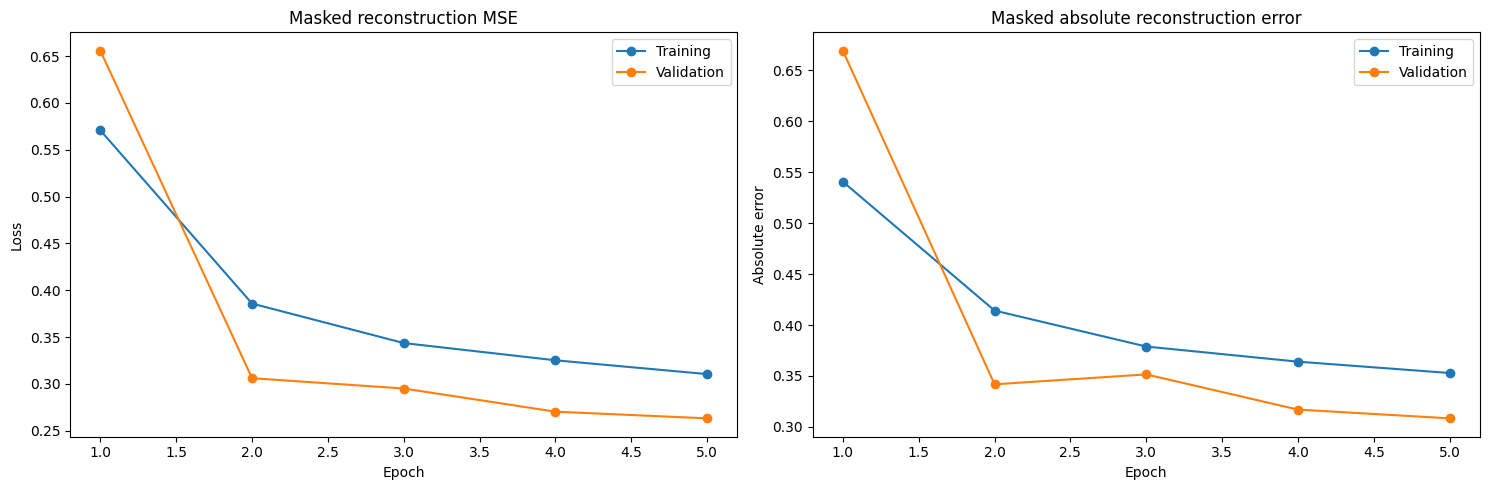

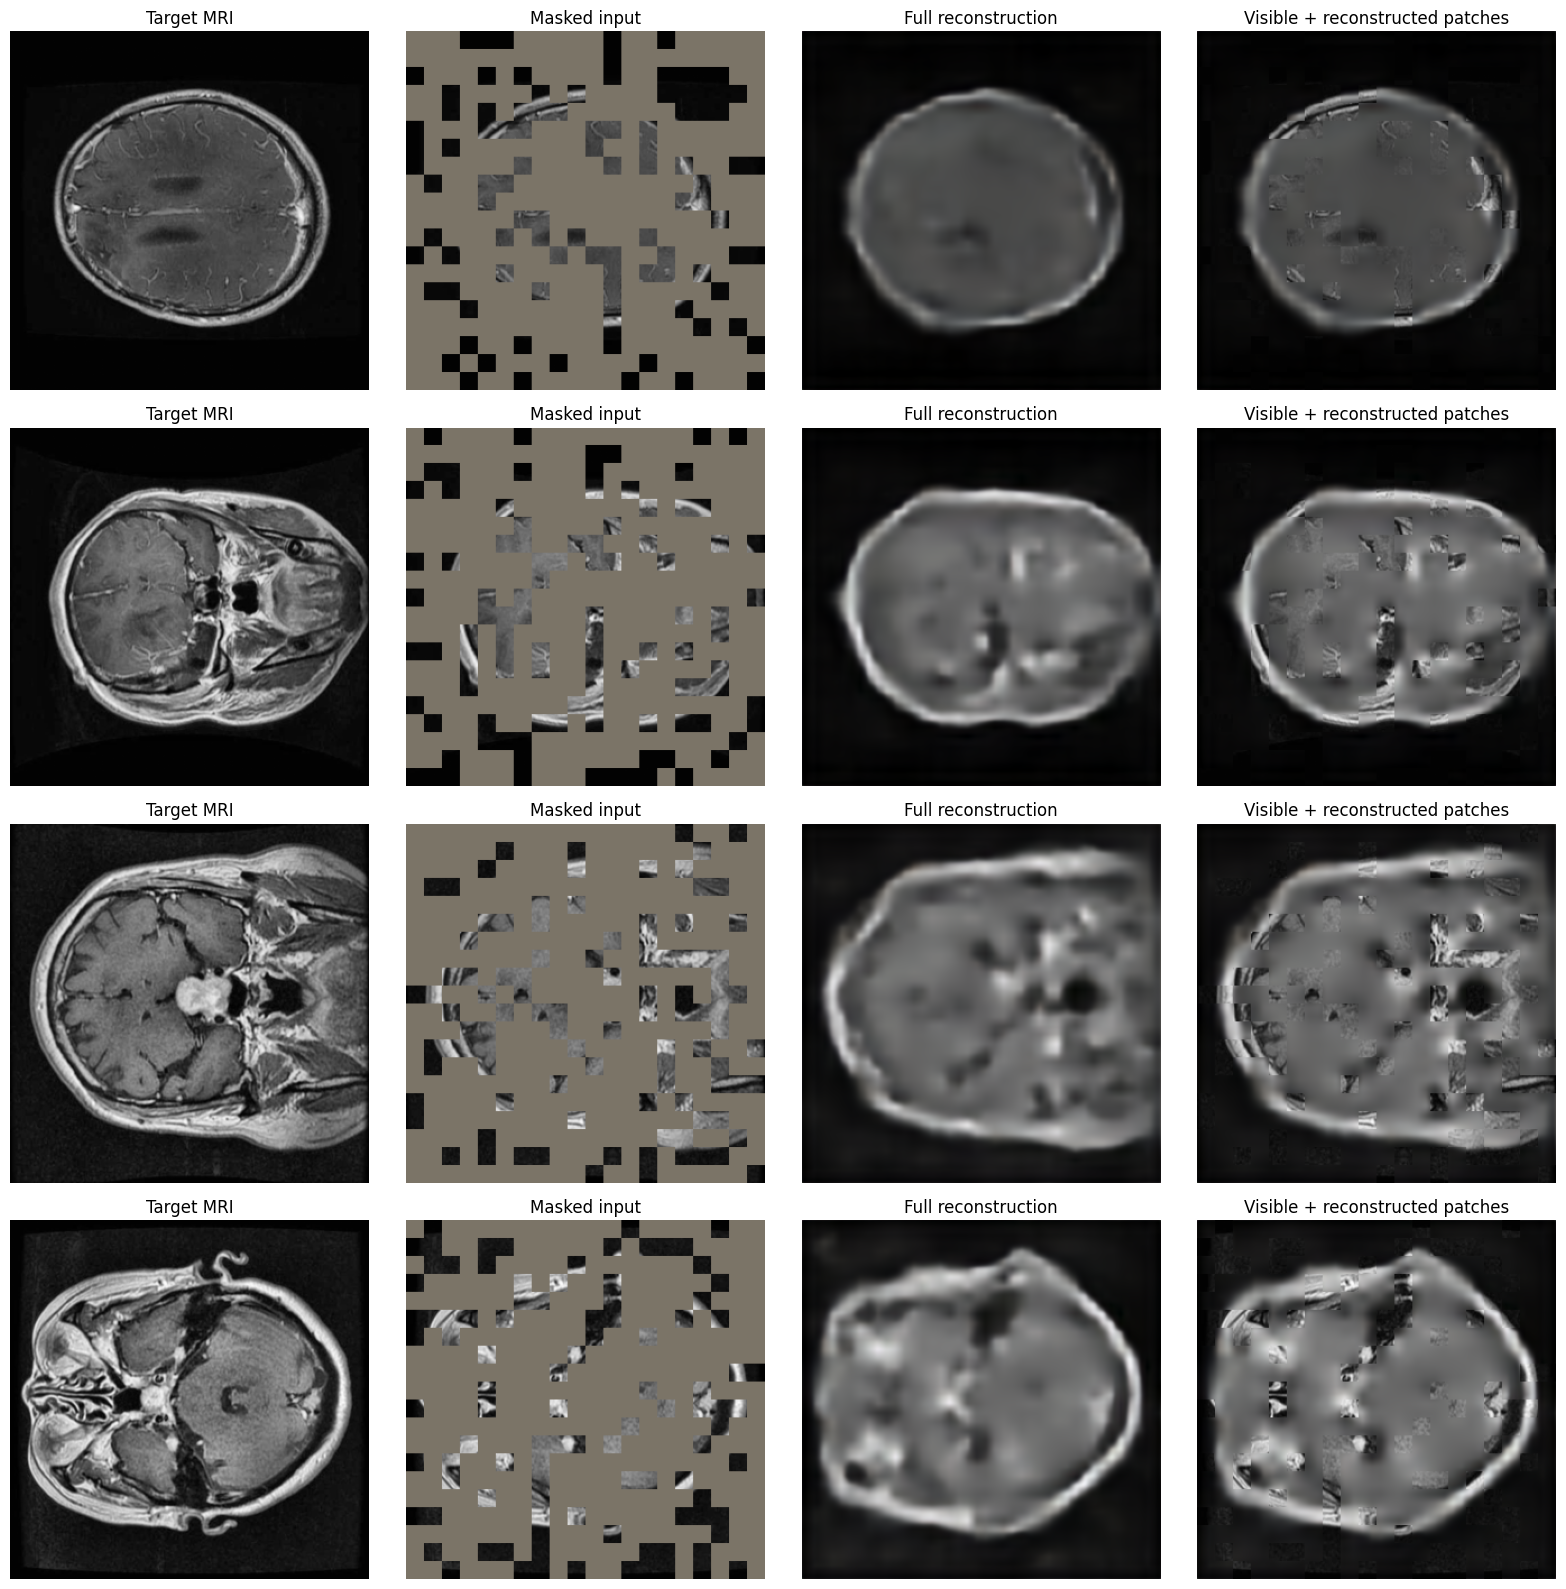

In [10]:
# Cell 10 — MAE training curves and reconstruction diagnostics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    ssl_history["epoch"],
    ssl_history["train_loss"],
    marker="o",
    label="Training",
)
axes[0].plot(
    ssl_history["epoch"],
    ssl_history["valid_loss"],
    marker="o",
    label="Validation",
)
axes[0].set_title("Masked reconstruction MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    ssl_history["epoch"],
    ssl_history["train_masked_mae"],
    marker="o",
    label="Training",
)
axes[1].plot(
    ssl_history["epoch"],
    ssl_history["valid_masked_mae"],
    marker="o",
    label="Validation",
)
axes[1].set_title("Masked absolute reconstruction error")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Absolute error")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    SSL_OUTPUT_DIR / "mae_training_curves.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

# Visualize target, masked input, reconstruction, and a composite in which
# reconstructed values are inserted only into the hidden regions.
visual_images = next(iter(ssl_valid_loader))
visual_images = move_to_device(visual_images[: min(4, len(visual_images))])
visual_masked, visual_pixel_mask, _ = create_random_patch_mask(
    visual_images,
    cfg.patch_size,
    cfg.mask_ratio,
)

mae_model.eval()
with torch.inference_mode():
    with amp_context():
        visual_reconstruction, _ = mae_model(visual_masked)

visual_composite = (
    visual_images * (1.0 - visual_pixel_mask)
    + visual_reconstruction * visual_pixel_mask
)

fig, axes = plt.subplots(len(visual_images), 4, figsize=(16, 4 * len(visual_images)))
axes = np.asarray(axes).reshape(len(visual_images), 4)

for row_index in range(len(visual_images)):
    panels = [
        (visual_images[row_index], "Target MRI"),
        (visual_masked[row_index], "Masked input"),
        (visual_reconstruction[row_index], "Full reconstruction"),
        (visual_composite[row_index], "Visible + reconstructed patches"),
    ]
    for column_index, (image_tensor, title) in enumerate(panels):
        axes[row_index, column_index].imshow(
            denormalise(image_tensor.float()).cpu().permute(1, 2, 0)
        )
        axes[row_index, column_index].set_title(title)
        axes[row_index, column_index].axis("off")

plt.tight_layout()
plt.savefig(
    SSL_OUTPUT_DIR / "mae_reconstruction_examples.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 3. Stage B — YOLOv26 segmentation fine-tuning

The MAE reconstruction decoder is no longer required. The trained YOLOv26 segmentation network is extracted from:

```python
unwrap_model(mae_model).encoder.segmentation_model
```

The notebook saves this network in an Ultralytics-compatible checkpoint and fine-tunes all of its parameters for two supervised epochs.

In [11]:
# Cell 11 — Save the MAE-initialized YOLOv26 segmenter and fine-tune
ssl_initialized_path = WORKING_ROOT / "yolov26_seg_mae_initialized.pt"

trained_mae_model = unwrap_model(mae_model)

# The encoder wraps the complete YOLOv26 segmentation network. Its weights
# were updated by masked reconstruction during Stage A.
ssl_segmentation_model = (
    trained_mae_model
    .encoder
    .segmentation_model
)

# Build an independent CPU model for an Ultralytics-compatible checkpoint.
checkpoint_model = copy.deepcopy(
    ssl_segmentation_model
).float().cpu()

for parameter in checkpoint_model.parameters():
    parameter.requires_grad = True

checkpoint_model.eval()

checkpoint = {
    "model": checkpoint_model,
    "ema": None,
    "optimizer": None,
    "train_args": {},
    "epoch": -1,
    "best_fitness": None,
    "date": pd.Timestamp.utcnow().isoformat(),
    "version": ultralytics.__version__,
    "license": "AGPL-3.0",
}

torch.save(checkpoint, ssl_initialized_path)
print("MAE-initialized YOLOv26 checkpoint saved to:", ssl_initialized_path)

# Supervised tumor-segmentation fine-tuning: exactly two epochs.
segmenter = YOLO(str(ssl_initialized_path))
train_results = segmenter.train(
    data=str(data_yaml),
    epochs=cfg.segmentation_epochs,
    imgsz=cfg.segmentation_image_size,
    batch=cfg.segmentation_batch_size,
    workers=cfg.num_workers,
    patience=cfg.segmentation_patience,
    seed=cfg.seed,
    deterministic=True,
    pretrained=False,
    project=str(SEGMENTATION_PROJECT_DIR),
    name="mae_yolov26_seg",
    exist_ok=True,
    plots=True,
    verbose=True,
)

best_segmenter_path = Path(segmenter.trainer.best)
print("Best segmenter:", best_segmenter_path)

MAE-initialized YOLOv26 checkpoint saved to: /kaggle/working/cse445_mae_yolov26/yolov26_seg_mae_initialized.pt
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cse445_mae_yolov26/brain_tumor_yolo_seg/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/k

In [12]:
# Cell 12 — Held-out tumor-segmentation evaluation
best_segmenter = YOLO(str(best_segmenter_path))

test_metrics = best_segmenter.val(
    data=str(data_yaml),
    split="test",
    imgsz=cfg.segmentation_image_size,
    batch=cfg.segmentation_batch_size,
    workers=cfg.num_workers,
    plots=True,
    project=str(SEGMENTATION_PROJECT_DIR),
    name="mae_yolov26_seg_test",
    exist_ok=True,
)

metrics_frame = pd.DataFrame([
    {"metric": key, "value": float(value)}
    for key, value in test_metrics.results_dict.items()
])
metrics_frame.to_csv(
    WORKING_ROOT / "mae_yolov26_seg_test_metrics.csv",
    index=False,
)
display(metrics_frame)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,469 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1175.7±376.8 MB/s, size: 37.0 KB)
val: Scanning /kaggle/working/cse445_mae_yolov26/brain_tumor_yolo_seg/labels/test... 215 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 215/215 1.2Kit/s 0.2s
val: New cache created: /kaggle/working/cse445_mae_yolov26/brain_tumor_yolo_seg/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 5.9it/s 4.6s
                   all        215        215      0.424      0.488      0.452      0.217      0.416      0.484      0.445      0.212
                     0        118        118      0.408      0.234      0.246      0.099      0.393      0.225      0.233        0.1
                     1         97         97    

,metric,value
0,metrics/precision(B),0.423502
1,metrics/recall(B),0.488090
2,metrics/mAP50(B),0.452059
3,metrics/mAP50-95(B),0.216594
4,metrics/precision(M),0.416105
5,metrics/recall(M),0.483853
6,metrics/mAP50(M),0.445053
7,metrics/mAP50-95(M),0.212087
8,fitness,0.428682


Results saved to /kaggle/working/cse445_mae_yolov26/segmentation_runs/qualitative_segmentation_predictions


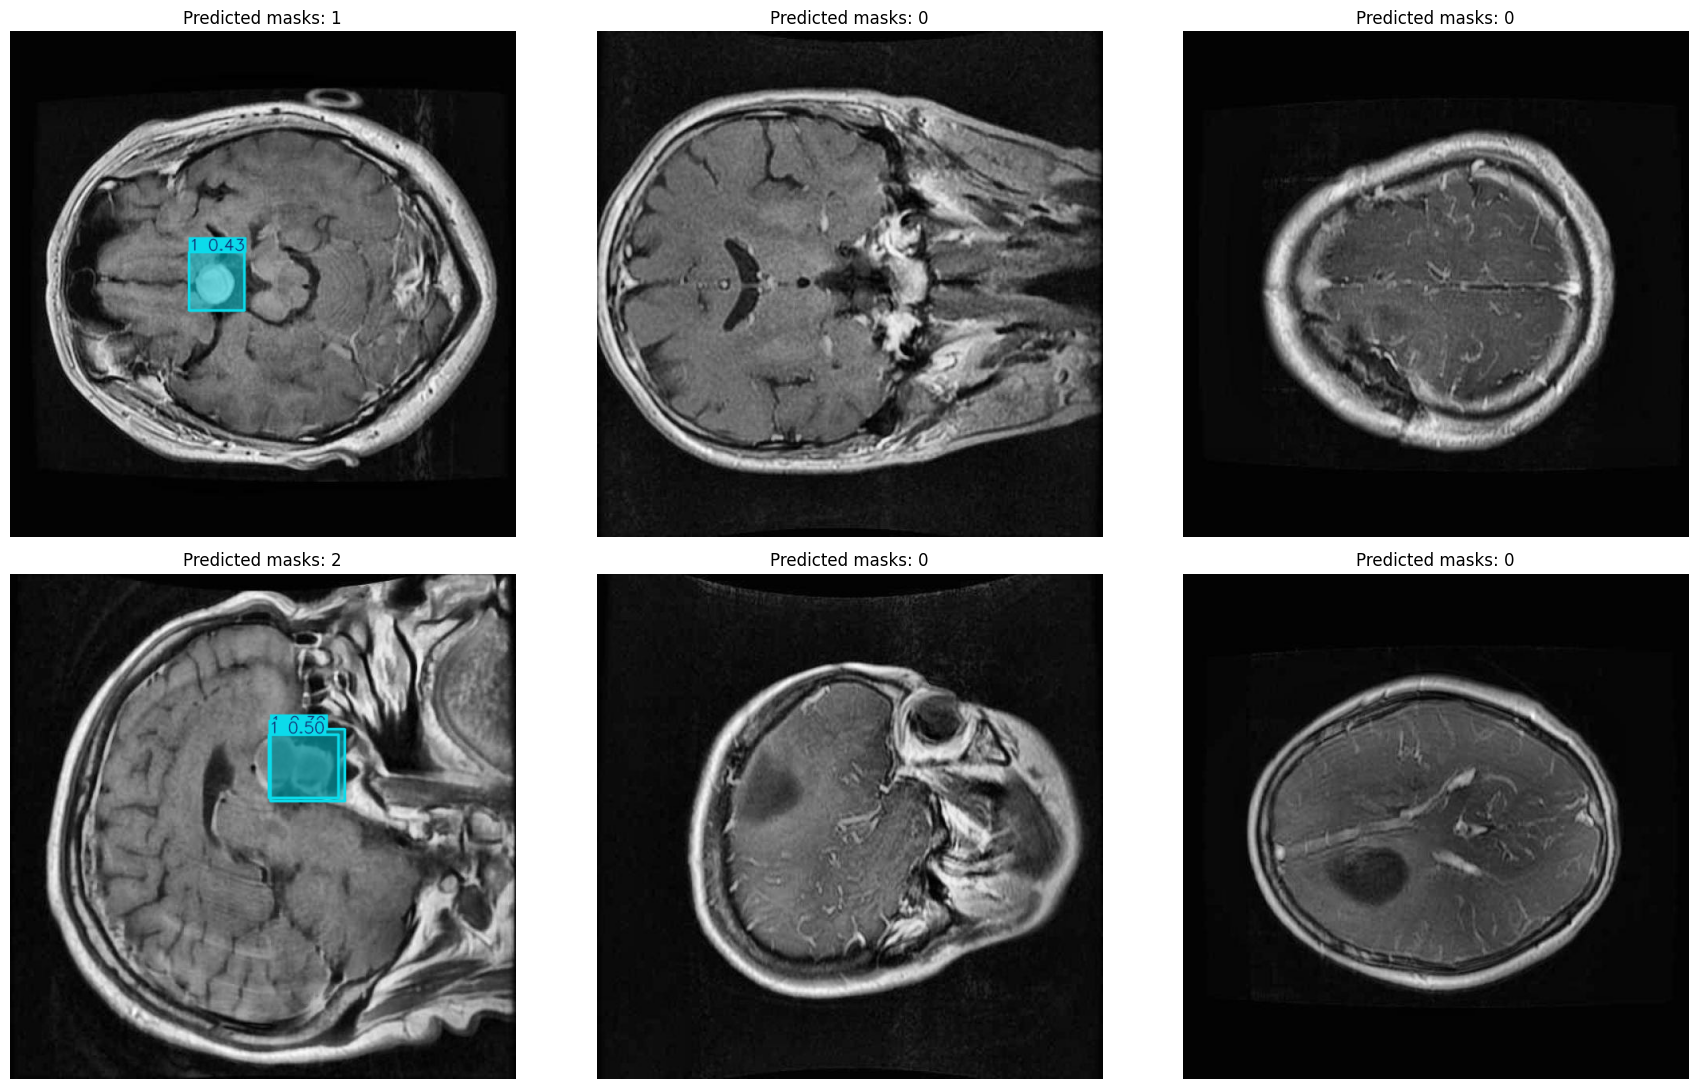

In [13]:
# Cell 13 — Qualitative tumor-mask predictions
number_of_test_images = int((manifest["split"] == "test").sum())
test_images = manifest.loc[
    manifest["split"] == "test",
    "image_path",
].sample(
    min(6, number_of_test_images),
    random_state=cfg.seed,
).tolist()

prediction_results = best_segmenter.predict(
    source=test_images,
    imgsz=cfg.segmentation_image_size,
    conf=0.25,
    iou=0.70,
    save=True,
    project=str(SEGMENTATION_PROJECT_DIR),
    name="qualitative_segmentation_predictions",
    exist_ok=True,
    verbose=False,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = np.asarray(axes).reshape(-1)

for axis, result in zip(axes, prediction_results):
    axis.imshow(result.plot()[:, :, ::-1])
    predicted_masks = 0 if result.masks is None else len(result.masks.data)
    axis.set_title(f"Predicted masks: {predicted_masks}")
    axis.axis("off")

for axis in axes[len(prediction_results):]:
    axis.axis("off")

plt.tight_layout()
plt.savefig(
    WORKING_ROOT / "qualitative_segmentation_predictions.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 4. Representation analysis

A two-dimensional t-SNE plot provides a qualitative view of the encoder representation before and after MAE training. Color denotes the number of annotated tumor objects in each image. This is a teaching diagnostic rather than a formal quantitative evaluation.

Extracting features:   0%|          | 0/27 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/27 [00:00<?, ?it/s]

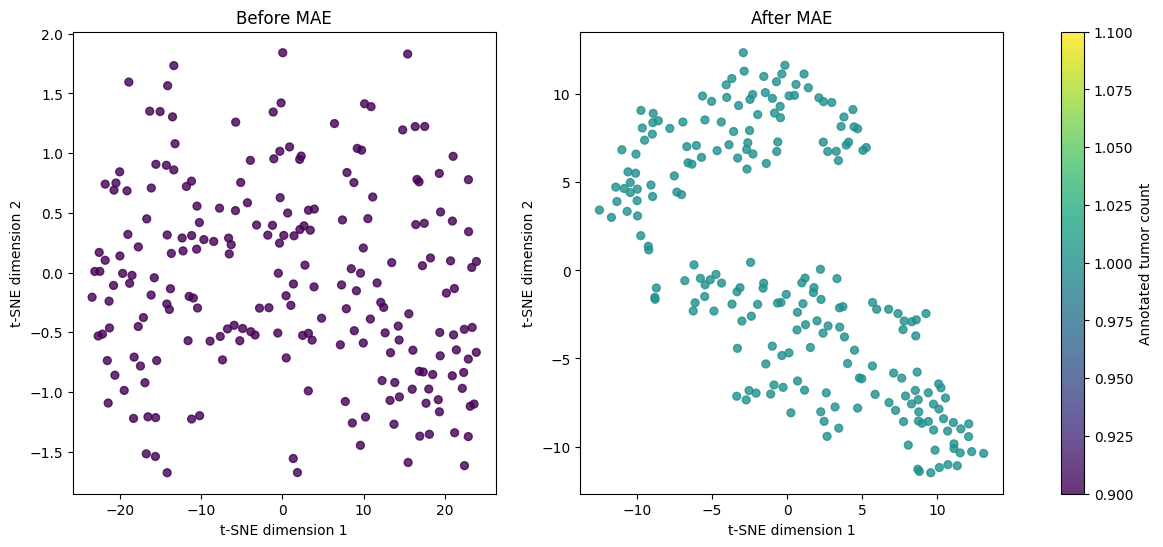

In [14]:
# Cell 14 — t-SNE before and after MAE
feature_frame = manifest[manifest["split"] == "test"].copy()
if len(feature_frame) > cfg.tsne_max_samples:
    feature_frame = feature_frame.sample(
        cfg.tsne_max_samples,
        random_state=cfg.seed,
    )

feature_loader = DataLoader(
    SingleViewDataset(feature_frame),
    batch_size=cfg.segmentation_batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=AMP_ENABLED,
)


def collect_features(extractor):
    extractor.eval()
    feature_values = []
    object_counts = []

    with torch.inference_mode():
        for images, mask_counts in tqdm(
            feature_loader,
            desc="Extracting features",
            leave=False,
        ):
            images = move_to_device(images)
            with amp_context():
                maps = extractor(images)
                pooled = torch.cat([
                    F.adaptive_avg_pool2d(feature_map, 1).flatten(1)
                    for feature_map in maps
                ], dim=1)

            feature_values.append(pooled.float().cpu().numpy())
            object_counts.append(mask_counts.numpy())

    return np.concatenate(feature_values), np.concatenate(object_counts)


mae_core = unwrap_model(mae_model)

after_features, mask_counts = collect_features(mae_core.encoder)

trained_feature_state = copy.deepcopy({
    key: value.detach().cpu()
    for key, value in mae_core.encoder.state_dict().items()
})

mae_core.encoder.load_state_dict(initial_feature_state)
mae_core.encoder.to(device)
before_features, _ = collect_features(mae_core.encoder)

# Restore the MAE-trained encoder after collecting the baseline features.
mae_core.encoder.load_state_dict(trained_feature_state)
mae_core.encoder.to(device)

sample_count = len(feature_frame)
if sample_count < 3:
    raise ValueError("At least three test images are required for t-SNE.")
perplexity = max(2, min(30, (sample_count - 1) // 3))

before_embedding = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=cfg.seed,
).fit_transform(before_features)

after_embedding = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=cfg.seed,
).fit_transform(after_features)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, embedding, title in [
    (axes[0], before_embedding, "Before MAE"),
    (axes[1], after_embedding, "After MAE"),
]:
    scatter = axis.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=mask_counts,
        s=32,
        alpha=0.8,
    )
    axis.set_title(title)
    axis.set_xlabel("t-SNE dimension 1")
    axis.set_ylabel("t-SNE dimension 2")

fig.colorbar(scatter, ax=axes, label="Annotated tumor count")
plt.savefig(
    SSL_OUTPUT_DIR / "tsne_before_after_mae.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## Recommended comparative experiment

To evaluate whether MAE initialization is useful, train the same YOLOv26 segmentation architecture under identical data splits and hyperparameters:

| Experiment | Initialization | SSL epochs | Segmentation epochs |
|---|---|---:|---:|
| A | Random YOLOv26 | 0 | 2 |
| B | MAE-trained YOLOv26 | 2 | 2 |
| C | Supervised pretrained weights, when available | 0 | 2 |

Record mask precision, mask recall, mask mAP@0.5, mask mAP@0.5:0.95, training time, and inference latency. For a research-quality comparison, increase training duration and repeat each configuration with multiple random seeds.

In [15]:
# Cell 15 — Output summary and optional archive
important_paths = [
    data_yaml,
    PREPARED_ROOT / "manifest.csv",
    SSL_OUTPUT_DIR / "mae_yolov26_checkpoint.pt",
    SSL_OUTPUT_DIR / "mae_history.csv",
    SSL_OUTPUT_DIR / "mae_training_curves.png",
    SSL_OUTPUT_DIR / "mae_reconstruction_examples.png",
    SSL_OUTPUT_DIR / "tsne_before_after_mae.png",
    WORKING_ROOT / "mae_yolov26_seg_test_metrics.csv",
    WORKING_ROOT / "qualitative_segmentation_predictions.png",
    ssl_initialized_path,
    best_segmenter_path,
]

print("Pipeline completed. Important artifacts:")
for path in important_paths:
    print(" -", path)

# Bundle the output directory for convenient Kaggle download.
archive_path = shutil.make_archive(
    str(WORKING_ROOT),
    "zip",
    root_dir=WORKING_ROOT,
)
print("Downloadable output archive:", archive_path)

Pipeline completed. Important artifacts:
 - /kaggle/working/cse445_mae_yolov26/brain_tumor_yolo_seg/data.yaml
 - /kaggle/working/cse445_mae_yolov26/brain_tumor_yolo_seg/manifest.csv
 - /kaggle/working/cse445_mae_yolov26/mae_outputs/mae_yolov26_checkpoint.pt
 - /kaggle/working/cse445_mae_yolov26/mae_outputs/mae_history.csv
 - /kaggle/working/cse445_mae_yolov26/mae_outputs/mae_training_curves.png
 - /kaggle/working/cse445_mae_yolov26/mae_outputs/mae_reconstruction_examples.png
 - /kaggle/working/cse445_mae_yolov26/mae_outputs/tsne_before_after_mae.png
 - /kaggle/working/cse445_mae_yolov26/mae_yolov26_seg_test_metrics.csv
 - /kaggle/working/cse445_mae_yolov26/qualitative_segmentation_predictions.png
 - /kaggle/working/cse445_mae_yolov26/yolov26_seg_mae_initialized.pt
 - /kaggle/working/cse445_mae_yolov26/segmentation_runs/mae_yolov26_seg/weights/best.pt
Downloadable output archive: /kaggle/working/cse445_mae_yolov26.zip


## Classroom interpretation guide

### What should happen during MAE pretraining?

- The masked-region reconstruction loss should generally decrease.
- Early reconstructions may be smooth because the decoder receives compressed multi-scale features.
- The encoder should learn anatomical structure, intensity patterns, and tumor-context cues without using polygon labels.

### What is transferred to segmentation?

Only the YOLOv26 segmentation network inside the MAE encoder is transferred. The reconstruction decoder is discarded.

### Why reconstruct only masked regions?

If the loss were dominated by visible pixels, the network could learn a nearly trivial identity mapping. Restricting the objective to hidden patches forces contextual inference.

### Why can two epochs look weak?

Two epochs are intended to verify the complete pipeline, not to establish the best representation. MAE commonly benefits from substantially longer pretraining.

### What does a lower reconstruction loss prove?

It proves that the model is improving at the pretext task. It does not, by itself, prove better tumor segmentation. Downstream metrics are required.

## Optional ways to optimize the MAE notebook further

### Longer training

```python
cfg.ssl_epochs = 50
cfg.segmentation_epochs = 50
```

### Mask ratio

Common values to test:

```python
cfg.mask_ratio = 0.50
cfg.mask_ratio = 0.75
cfg.mask_ratio = 0.90
```

A high mask ratio makes the task harder and increases the need for contextual reasoning.

### Patch size

```python
cfg.patch_size = 8
cfg.patch_size = 16
cfg.patch_size = 32
```

Smaller patches preserve finer boundaries but increase the number of mask units.

### Effective batch size

```python
cfg.ssl_batch_size = 6
cfg.gradient_accumulation_steps = 4
```

$$
B_{\mathrm{effective}}
=
B_{\mathrm{physical}}
\times
N_{\mathrm{accumulation}}.
$$

### Memory reduction

```python
cfg.ssl_image_size = 224
cfg.decoder_dim = 96
cfg.segmentation_batch_size = 4
```

### Stronger YOLOv26 model

```python
cfg.yolo_model = "yolo26s-seg.yaml"
```

### Faster execution

```python
cfg.use_torch_compile = True
cfg.num_workers = 4
cfg.prefetch_factor = 4
```

### Research-quality evaluation

- pretrain for many more epochs;
- use three or more random seeds;
- compare against random, supervised, SimCLR, MoCo, and BYOL initialization;
- report confidence intervals;
- evaluate label efficiency with 10%, 25%, 50%, and 100% of segmentation labels;
- monitor both reconstruction performance and downstream segmentation performance.